# 02 — Model Training

Fine-tune EfficientNet-B0 on CIFAKE + GenImage for binary classification (REAL vs AI-GENERATED).

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
import pandas as pd
from PIL import Image
from pathlib import Path
import numpy as np

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cpu


In [2]:
PROCESSED = Path('../data/processed')
WEIGHTS_OUT = Path('../backend/model/weights/efficientnet_b0_finetuned.pth')
WEIGHTS_OUT.parent.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 15
LR = 1e-4
PATIENCE = 3   # early stopping

## Dataset & Transforms

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class AIDetectionDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, int(row['label'])

train_ds = AIDetectionDataset(PROCESSED / 'train.csv', train_transform)
val_ds   = AIDetectionDataset(PROCESSED / 'val.csv',   val_transform)

# Weighted sampler to handle class imbalance
labels = train_ds.df['label'].values
class_counts = np.bincount(labels)
class_weights = 1.0 / class_counts
sample_weights = class_weights[labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 2625 | Val batches: 563


## Model Definition

In [4]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features, 2),
)
model = model.to(DEVICE)

# Phase 1: freeze backbone, train head only
for name, param in model.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params (phase 1): {trainable:,}')

Trainable params (phase 1): 2,562


## Training Loop

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_loss = float('inf')
patience_counter = 0
history = []

for epoch in range(1, EPOCHS + 1):
    # Phase 2: unfreeze all layers after epoch 3
    if epoch == 4:
        for param in model.parameters():
            param.requires_grad = True
        optimizer = optim.AdamW(model.parameters(), lr=LR / 5, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - 3)
        print('--- Backbone unfrozen ---')

    # Train
    model.train()
    train_loss, train_correct = 0.0, 0
    for images, labels_batch in train_loader:
        images, labels_batch = images.to(DEVICE), labels_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels_batch).sum().item()

    # Validate
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for images, labels_batch in val_loader:
            images, labels_batch = images.to(DEVICE), labels_batch.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels_batch)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels_batch).sum().item()

    train_loss /= len(train_ds)
    val_loss   /= len(val_ds)
    train_acc   = train_correct / len(train_ds)
    val_acc     = val_correct   / len(val_ds)

    scheduler.step()
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss,
                    'train_acc': train_acc, 'val_acc': val_acc})
    print(f'Epoch {epoch:2d} | train_loss={train_loss:.4f} acc={train_acc:.4f} | '
          f'val_loss={val_loss:.4f} acc={val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), WEIGHTS_OUT)
        print(f'  -> Saved best model (val_loss={val_loss:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nBest val_loss: {best_val_loss:.4f}')
print(f'Weights saved to: {WEIGHTS_OUT}')

Epoch  1 | train_loss=0.4371 acc=0.8088 | val_loss=0.3945 acc=0.8302
  -> Saved best model (val_loss=0.3945)
Epoch  2 | train_loss=0.3728 acc=0.8381 | val_loss=0.3738 acc=0.8393
  -> Saved best model (val_loss=0.3738)
Epoch  3 | train_loss=0.3617 acc=0.8422 | val_loss=0.3591 acc=0.8467
  -> Saved best model (val_loss=0.3591)
--- Backbone unfrozen ---


KeyboardInterrupt: 

## Training Curves

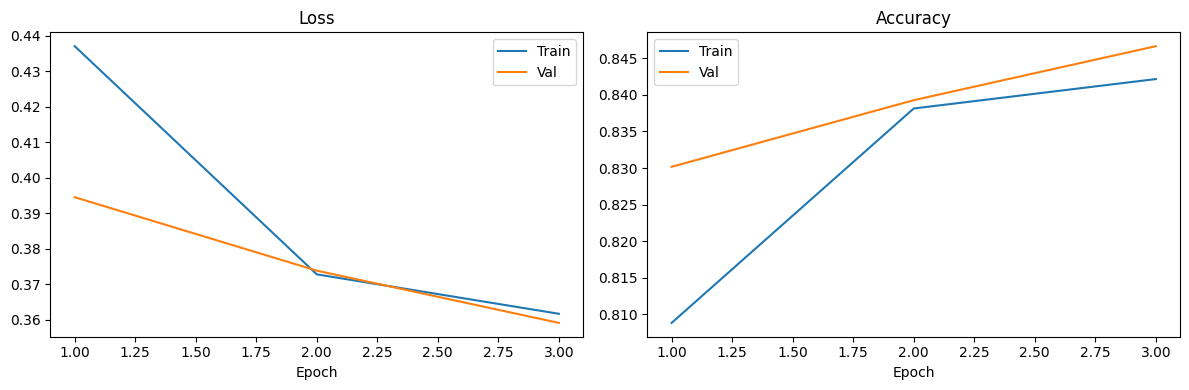

In [6]:
import matplotlib.pyplot as plt
hist_df = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_df['epoch'], hist_df['train_loss'], label='Train')
ax1.plot(hist_df['epoch'], hist_df['val_loss'],   label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(hist_df['epoch'], hist_df['train_acc'], label='Train')
ax2.plot(hist_df['epoch'], hist_df['val_acc'],   label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()